

**Nombre completo:** Benjamin Naranjo
**RUT:** 21687575-3
**Fecha:** 10/06/2026  


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import time
import json

In [2]:
#Petición GET a Open-Meteo 
url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude":  -33.45,   # Latitud de Santiago
    "longitude": -70.65,   # Longitud de Santiago
    "current":   "temperature_2m,windspeed_10m,weathercode"
}

response = requests.get(url, params=params, timeout=10)
response.raise_for_status()   # lanza excepción si código >= 400

data = response.json()

print(f"Código de estado : {response.status_code}")
print(f"URL final        : {response.url}")
print(f"Clima actual     : {data['current']}")

Código de estado : 200
URL final        : https://api.open-meteo.com/v1/forecast?latitude=-33.45&longitude=-70.65&current=temperature_2m%2Cwindspeed_10m%2Cweathercode
Clima actual     : {'time': '2026-06-10T16:30', 'interval': 900, 'temperature_2m': 9.9, 'windspeed_10m': 2.7, 'weathercode': 51}


In [3]:
#Explorar la estructura completa de la respuesta JSON
print("Claves principales:", list(data.keys()))

# Ver el JSON formateado con indentación de 2 espacios
print(json.dumps(data, indent=2))

Claves principales: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'current_units', 'current']
{
  "latitude": -33.427067,
  "longitude": -70.64276,
  "generationtime_ms": 0.07426738739013672,
  "utc_offset_seconds": 0,
  "timezone": "GMT",
  "timezone_abbreviation": "GMT",
  "elevation": 554.0,
  "current_units": {
    "time": "iso8601",
    "interval": "seconds",
    "temperature_2m": "\u00b0C",
    "windspeed_10m": "km/h",
    "weathercode": "wmo code"
  },
  "current": {
    "time": "2026-06-10T16:30",
    "interval": 900,
    "temperature_2m": 9.9,
    "windspeed_10m": 2.7,
    "weathercode": 51
  }
}




¿Qué ocurre si cambias timeout=10 por timeout=0.00001? ¿Qué excepción se lanza?

Con un timeout tan pequeño , la conexión no alcanza a establecerse antes de que expire el tiempo límite, por lo que requests interrumpe la petición y provoca esta excepción:
requests.exceptions.ConnectTimeout

¿Qué diferencia hay entre response.text y response.json()?

response.text devuelve el cuerpo de la respuesta como un string. En cambio response.json() devuelve esa misma cadena y la convierte en un diccionario o lista, lo que permite acceder a los datos directamente con índices.

Identifica en response.url cómo fueron codificados los parámetros que pasaste en params. 

Los parámetros aparecen después del signo ? en la URL, separados por &, con el formato clave=valor. Al usar params={}, requests codifica automáticamente los caracteres especiales, usando codificación URL, evitando errores manuales.

In [4]:
#Implementar la función get_seguro() con manejo completo de errores

def get_seguro(url, params=None, timeout=10):
    """
    GET robusto con manejo de errores.
    Retorna el dict JSON o None si ocurre cualquier error.
    """
    
    try:
        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        return r.json()

    except requests.exceptions.Timeout:
        print(f"[ERROR] Timeout: la API no respondió en {timeout}s")

    except requests.exceptions.HTTPError as e:
        codigo = e.response.status_code
        print(f"[ERROR] HTTP {codigo}: {e.response.reason}")
        if codigo == 404:
            print("Endpoint no encontrado. Revisa la URL.")
        elif codigo == 429:
            print("Límite de peticiones excedido. Usar time.sleep().")
        elif codigo == 401:
            print(" No autorizado. Verificar API key.")

    except requests.exceptions.ConnectionError:
        print("[ERROR] Sin conexión o host inválido")

    except requests.exceptions.RequestException as e:
        print(f"[ERROR] Error inesperado: {e}")

    return None

print("Función get_seguro() definida correctamente.")

Función get_seguro() definida correctamente.


In [5]:
#Probar la función con distintos escenarios de error
# Caso 1: URL válida — debe retornar datos
r1 = get_seguro(
    "https://api.open-meteo.com/v1/forecast",
    params={"latitude": -33.45, "longitude": -70.65, "current": "temperature_2m"}
)
print("Caso 1 (válido):", r1["current"] if r1 else "None")

# Caso 2: Endpoint inexistente — debe mostrar error 404
r2 = get_seguro("https://api.open-meteo.com/v1/ruta_invalida")
print("Caso 2 (404):", r2)
print()

# Caso 3: Timeout muy bajo — debe mostrar error de timeout
r3 = get_seguro("https://api.open-meteo.com/v1/forecast", timeout=0.00001)
print("Caso 3 (timeout):", r3)

Caso 1 (válido): {'time': '2026-06-10T16:30', 'interval': 900, 'temperature_2m': 9.9}
[ERROR] HTTP 404: Not Found
Endpoint no encontrado. Revisa la URL.
Caso 2 (404): None

[ERROR] Timeout: la API no respondió en 1e-05s
Caso 3 (timeout): None


¿Por qué es obligatorio usar timeout?

Sin timeout, si el servidor no responde, el script queda bloqueado indefinidamente esperando. Esto puede congelar un pipeline de datos completo. Con timeout` se garantiza que la petición falle rápido y el programa pueda recuperarse o reintentar.

¿Qué hace raise_for_status()?  
Revisa el código de estado HTTP de la respuesta. Si es 4xx o 5xx, lanza automáticamente una excepción HTTPError. Sin esta línea, el script continuaría ejecutándose incluso ante respuestas de error.

¿Cuándo usarías cada excepción?  
Timeout: cuando el servidor tarda demasiado.  
HTTPError: cuando el servidor responde pero con un código de error.
ConnectionError: cuando no hay red, el DNS falla o el host no existe.  
RequestException:Para cualquier otro error inesperado de requests.

¿Por qué es peligroso un script sin timeout= que consume APIs externas?

Puede bloquear el proceso completo de forma indefinida. En entornos de producción, esto desperdicia recursos del sistema y puede impedir que el resto del código se ejecute.

¿Qué estrategia usarías si la API retorna 429 de forma intermitente?

Implementar exponential backoff que es esperar un tiempo creciente entre reintentos (time.sleep(2**intento)). También se puede llevar un contador de reintentos máximos.

¿Qué diferencia hay entre ConnectionError y Timeout en términos de causa?

ConnectionError ocurre cuando no se puede establecer la conexión. Timeout ocurre cuando la conexión sí se establece pero el servidor no envía respuesta dentro del tiempo límite establecido.

In [12]:
# Implementar la función de paginación

def consumir_paginado(url, limite=20, max_paginas=20):
    """
    Consume una API con paginación tipo page+limit.
    Retorna lista con todos los registros.
    """
    todos = []
    pagina = 1

    while pagina <= max_paginas:
        resultado = get_seguro(url, params={"_page": pagina, "_limit": limite})

        if resultado is None:    # error en la petición
            break
        if not resultado:        # lista vacía = no hay más datos
            print(f"  Fin de datos en página {pagina}")
            break

        todos.extend(resultado)
        print(f"  Página {pagina:2d}: {len(resultado):3d} registros | Total: {len(todos)}")
        pagina += 1
        time.sleep(0.1)   # cortesía al servidor

    return todos

In [7]:
# Consumir todos los posts de JSONPlaceholder y crear el DataFrame

print("Descargando posts...")
posts = consumir_paginado(
    "https://jsonplaceholder.typicode.com/posts",
    limite=20
)

df_posts = pd.DataFrame(posts)

print(f"\nForma del DataFrame: {df_posts.shape}")
print("\nPrimeras filas:")
print(df_posts.head())
print("\nTipos de datos:")
print(df_posts.dtypes)

Descargando posts...
  Página  1:  20 registros | Total: 20
  Página  2:  20 registros | Total: 40
  Página  3:  20 registros | Total: 60
  Página  4:  20 registros | Total: 80
  Página  5:  20 registros | Total: 100
  Fin de datos en página 6

Forma del DataFrame: (100, 4)

Primeras filas:
   userId  id                                              title  \
0       1   1  sunt aut facere repellat provident occaecati e...   
1       1   2                                       qui est esse   
2       1   3  ea molestias quasi exercitationem repellat qui...   
3       1   4                               eum et est occaecati   
4       1   5                                 nesciunt quas odio   

                                                body  
0  quia et suscipit\nsuscipit recusandae consequu...  
1  est rerum tempore vitae\nsequi sint nihil repr...  
2  et iusto sed quo iure\nvoluptatem occaecati om...  
3  ullam et saepe reiciendis voluptatem adipisci\...  
4  repudiandae veniam qu

In [8]:
# Calcular estadísticas por usuario y exportar a CSV

# Estadísticas por userId
resumen = df_posts.groupby("userId").agg(
    total_posts   = ("id",   "count"),
    largo_promedio = ("body", lambda x: x.str.len().mean().round(1))
).reset_index()

print(resumen)

# Exportar a CSV
df_posts.to_csv("posts.csv", index=False)
resumen.to_csv("resumen_usuarios.csv", index=False)
print("\nArchivos CSV exportados correctamente.")

   userId  total_posts  largo_promedio
0       1           10           164.5
1       2           10           162.9
2       3           10           153.8
3       4           10           182.3
4       5           10           162.5
5       6           10           147.0
6       7           10           163.5
7       8           10           160.6
8       9           10           154.6
9      10           10           154.7

Archivos CSV exportados correctamente.


¿Qué ocurre si la API devuelve una lista vacía en la primera página?

La función entra al bloque if not resultado, imprime el mensaje de fin de datos y rompe el loop inmediatamente. La lista todos queda vacía y el DataFrame resultante tendrá 0 filas.

¿Para qué sirve el parámetro max_paginas en la función?

 Si la API no devuelve lista vacía al terminar sus datos, max_paginas evita que el loop sea infinito, limitando el máximo de peticiones que se realizarán.

¿Qué ventaja ofrece pd.DataFrame(lista_de_dicts) frente a construir el DataFrame manualmente?

Tiene la ventaja que este infiere automáticamente los nombres de columnas desde las claves del diccionario, detecta los tipos de datos, y lo hace en una sola línea de código. Construirlo manualmente requeriría crear listas separadas por columna, manejar valores faltantes y asignar tipos.

In [9]:
# Función de extracción y consumo de las tres ciudades

def obtener_clima(lat, lon, dias=3):
    """Retorna DataFrame con temperatura horaria para una ubicación."""
    data = get_seguro(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude":    lat,
            "longitude":   lon,
            "hourly":      "temperature_2m,precipitation_probability",
            "forecast_days": dias,
            "timezone":    "America/Santiago"
        }
    )
    if data is None:
        return None
    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    return df


CIUDADES = {
    "Santiago":    (-33.45, -70.65),
    "Concepcion":  (-36.82, -73.04),
    "Antofagasta": (-23.65, -70.40),
}

datos = {}
for ciudad, (lat, lon) in CIUDADES.items():
    print(f"Extrayendo {ciudad}...")
    datos[ciudad] = obtener_clima(lat, lon, dias=3)
    time.sleep(0.3)

print("Extracción completa.")

Extrayendo Santiago...
Extrayendo Concepcion...
Extrayendo Antofagasta...
Extracción completa.


In [10]:
#Estadísticas diarias por ciudad y concatenación

frames = []
for ciudad, df in datos.items():
    if df is not None:
        df["ciudad"] = ciudad
        df["fecha"]  = df["time"].dt.date
        frames.append(df)

df_all = pd.concat(frames, ignore_index=True)

resumen_diario = df_all.groupby(["ciudad", "fecha"]).agg(
    temp_max  = ("temperature_2m", "max"),
    temp_min  = ("temperature_2m", "min"),
    temp_prom = ("temperature_2m", "mean"),
).round(1).reset_index()

print(resumen_diario)

        ciudad       fecha  temp_max  temp_min  temp_prom
0  Antofagasta  2026-06-10      17.8      13.8       15.6
1  Antofagasta  2026-06-11      18.6      14.6       16.1
2  Antofagasta  2026-06-12      18.7      14.1       16.3
3   Concepcion  2026-06-10      13.4       7.4       10.8
4   Concepcion  2026-06-11      11.8       4.7        8.4
5   Concepcion  2026-06-12      11.6       8.5       10.4
6     Santiago  2026-06-10      11.5       7.1        8.9
7     Santiago  2026-06-11      16.0       3.4        9.6
8     Santiago  2026-06-12      19.1      10.6       13.9


CSV exportado: resumen_clima.csv


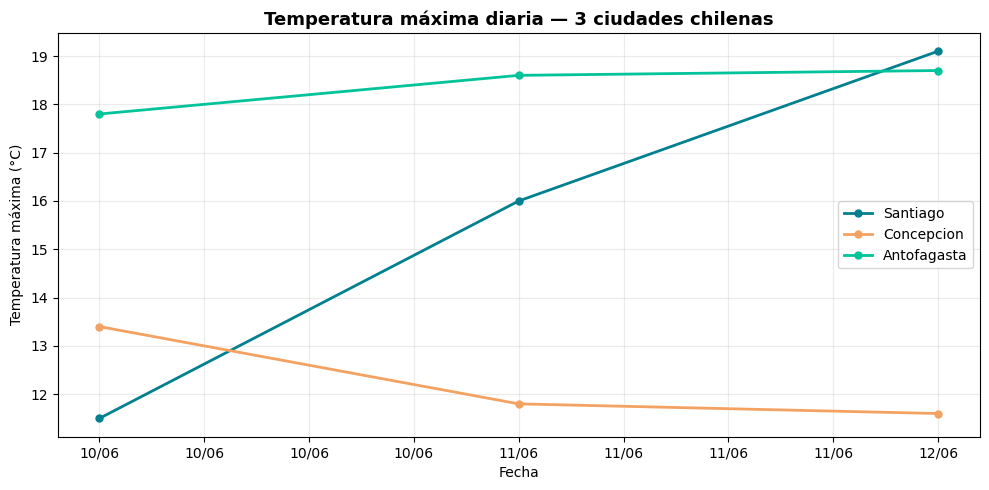

Gráfico guardado: comparacion_temp.png


In [11]:
#Exportar CSV y generar gráfico comparativo

# --- Load ---
resumen_diario.to_csv("resumen_clima.csv", index=False)
print("CSV exportado: resumen_clima.csv")

# --- Visualizar ---
fig, ax = plt.subplots(figsize=(10, 5))

colores = ["#028090", "#F4A261", "#02C39A"]

for ciudad, color in zip(CIUDADES.keys(), colores):
    df_c   = resumen_diario[resumen_diario["ciudad"] == ciudad]
    fechas = pd.to_datetime(df_c["fecha"])
    ax.plot(fechas, df_c["temp_max"],
            marker="o", label=ciudad,
            color=color, linewidth=2, markersize=5)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.set_title("Temperatura máxima diaria — 3 ciudades chilenas",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Temperatura máxima (°C)")
ax.set_xlabel("Fecha")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("comparacion_temp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado: comparacion_temp.png")


¿Por qué es importante llamar plt.tight_layout() antes de savefig()?

tight_layout() ajusta automáticamente los márgenes y el espaciado entre elementos del gráfico para que no queden mal en el grafico. Si se llama savefig() antes, el PNG puede guardarse con texto recortadoo.

¿Cómo modificarías el código para agregar una cuarta ciudad sin cambiar la estructura principal?

LO que modificaria seria agregar al diccionario CIUDADES con las coordenadas de la nueva ciudad, y añadir un color más a la lista colores. 


Describe el pipeline ETL que implementaste en esta actividad con tus propias palabras.

Extract: Se consultó la API de Open-Meteo para obtener datos horarios de temperatura de tres ciudades chilenas. Cada respuesta JSON se transformó en un DataFrame de pandas.  
Transform: Se agregaron columnas de ciudad y fecha, se concatenaron los tres DataFrames en uno solo, y se calcularon las estadísticas diarias (máxima, mínima y promedio de temperatura) agrupando por ciudad y fecha.  
Load:El resumen transformado se exportó a un archivo CSV (resumen_clima.csv) y se generó un gráfico comparativo guardado como PNG (comparacion_temp.png), dejando los datos listos para ser consultados o presentados.